# Distribution of the error on differet code sizes

In [1]:
# !pip3 install galois 
# !pip3 install func-timeout

In [ ]:
# libraries
import time
import galois
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import math

import networkx as nx

from func_timeout import func_timeout, FunctionTimedOut

from tqdm import tqdm

In [3]:
# Generate synthetic LEP monomial data
SEED = 26
NUM_SAMPLES = 1000
N_SIZES = [64, 128, 256, 512]
K_SIZES = [16, 64, 126, 274]
Q_SIZES = [5, 31, 127, 127]
ALPHA = 0.01
BETA = 0.2

In [4]:
def generate_pep_noise_data(num_samples, n_sizes, alpha, beta):
    """
    Genera datos para PEP: Matriz de Permutación P (original) y P_noisy (hint).
    """
    data = []
    for n in n_sizes:
        for _ in range(num_samples):
            # matriz de permutación original (P)
            P = np.zeros((n, n), dtype=int)
            perm = np.random.permutation(n)
            P[np.arange(n), perm] = 1
            
            P_noisy = P.copy()
            
            # aplicar beta (1 pasa a 0)
            mask_ones = (P == 1)
            noise_beta = np.random.random(P.shape) < beta
            P_noisy[mask_ones & noise_beta] = 0
            
            # aplicar alpha (0 pasa a 1)
            mask_zeros = (P == 0)
            noise_alpha = np.random.random(P.shape) < alpha
            P_noisy[mask_zeros & noise_alpha] = 1
            
            data.append({
                'n': n,
                'original': P,
                'noisy': P_noisy
            })
    return data

In [5]:
# ejemplo de generacion de datos
generate_pep_noise_data(1, [5], ALPHA, BETA)

[{'n': 5,
  'original': array([[0, 0, 0, 0, 1],
         [0, 0, 0, 1, 0],
         [1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 1, 0, 0, 0]]),
  'noisy': array([[0, 0, 0, 0, 1],
         [0, 0, 0, 1, 0],
         [1, 0, 0, 0, 0],
         [0, 0, 1, 0, 0],
         [0, 1, 0, 0, 0]])}]

In [6]:
def analyze_pep_noise(data, alpha_theo, beta_theo):
    stats = []
    all_col_weights = []

    for entry in data:
        orig, noisy, n = entry['original'], entry['noisy'], entry['n']
        
        # calculate noise rates
        alpha_hits = np.sum((orig == 0) & (noisy == 1))
        emp_alpha = alpha_hits / (n**2 - n)
        
        beta_hits = np.sum((orig == 1) & (noisy == 0))
        emp_beta = beta_hits / n
        
        # hamming weights per col
        col_weights = np.sum(noisy, axis=0)
        for w in col_weights:
            all_col_weights.append({'n': n, 'weight': w})
        
        # col classification
        survived = (orig == 1) & (noisy == 1)
        
        # unchanged: weight 1 and original exists
        unchanged = np.sum((col_weights == 1) & np.any(survived, axis=0))
        # ambiguous: weight > 1 and original exists
        ambiguous = np.sum((col_weights > 1) & np.any(survived, axis=0))
        # lost: original is gone
        lost = np.sum(~np.any(survived, axis=0))
        
        stats.append({
            'n': n,
            'emp_alpha': emp_alpha,
            'emp_beta': emp_beta,
            'unchanged': unchanged,
            'ambiguous': ambiguous,
            'lost': lost,
            'max_weight': np.max(col_weights)
        })
    
    df_samples = pd.DataFrame(stats)
    df_weights = pd.DataFrame(all_col_weights)
    
    # plotting
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    sns.set_style("whitegrid")
    cmap = "viridis"
    
    # empirical vs theoretical noise
    summary_noise = df_samples.groupby('n')[['emp_alpha', 'emp_beta']].mean().reset_index()
    noise_melted = summary_noise.melt(id_vars='n', var_name='metric', value_name='rate')
    sns.barplot(x='n', y='rate', hue='metric', data=noise_melted, ax=axes[0, 0], palette=cmap)
    axes[0, 0].axhline(alpha_theo, color='blue', linestyle='--', label=f'theo alpha ({alpha_theo})')
    axes[0, 0].axhline(beta_theo, color='red', linestyle='--', label=f'theo beta ({beta_theo})')
    axes[0, 0].set_title('Noise accuracy: empirical vs theoretical', fontsize=14)
    axes[0, 0].legend()

    # hamming weight distribution
    sns.boxplot(x='n', y='weight', data=df_weights, ax=axes[0, 1], palette=cmap, hue='n', legend=False)
    axes[0, 1].set_title('Column hamming weights distribution', fontsize=14)

    # structural integrity
    df_struct = df_samples.groupby('n')[['unchanged', 'ambiguous', 'lost']].mean().reset_index()
    struct_melted = df_struct.melt(id_vars='n', var_name='status', value_name='count')
    sns.barplot(x='n', y='count', hue='status', data=struct_melted, ax=axes[1, 0], palette=cmap)
    axes[1, 0].set_title('Column structural status', fontsize=14)

    # maximum column weight
    sns.boxplot(x='n', y='max_weight', data=df_samples, ax=axes[1, 1], palette=cmap, hue='n', legend=False)
    axes[1, 1].set_title('Maximum column weight', fontsize=14)

    plt.suptitle(f'pep noise analysis (alpha={alpha_theo}, beta={beta_theo})', fontsize=20, y=1.02)
    plt.tight_layout()
    plt.show()
    
    return df_samples

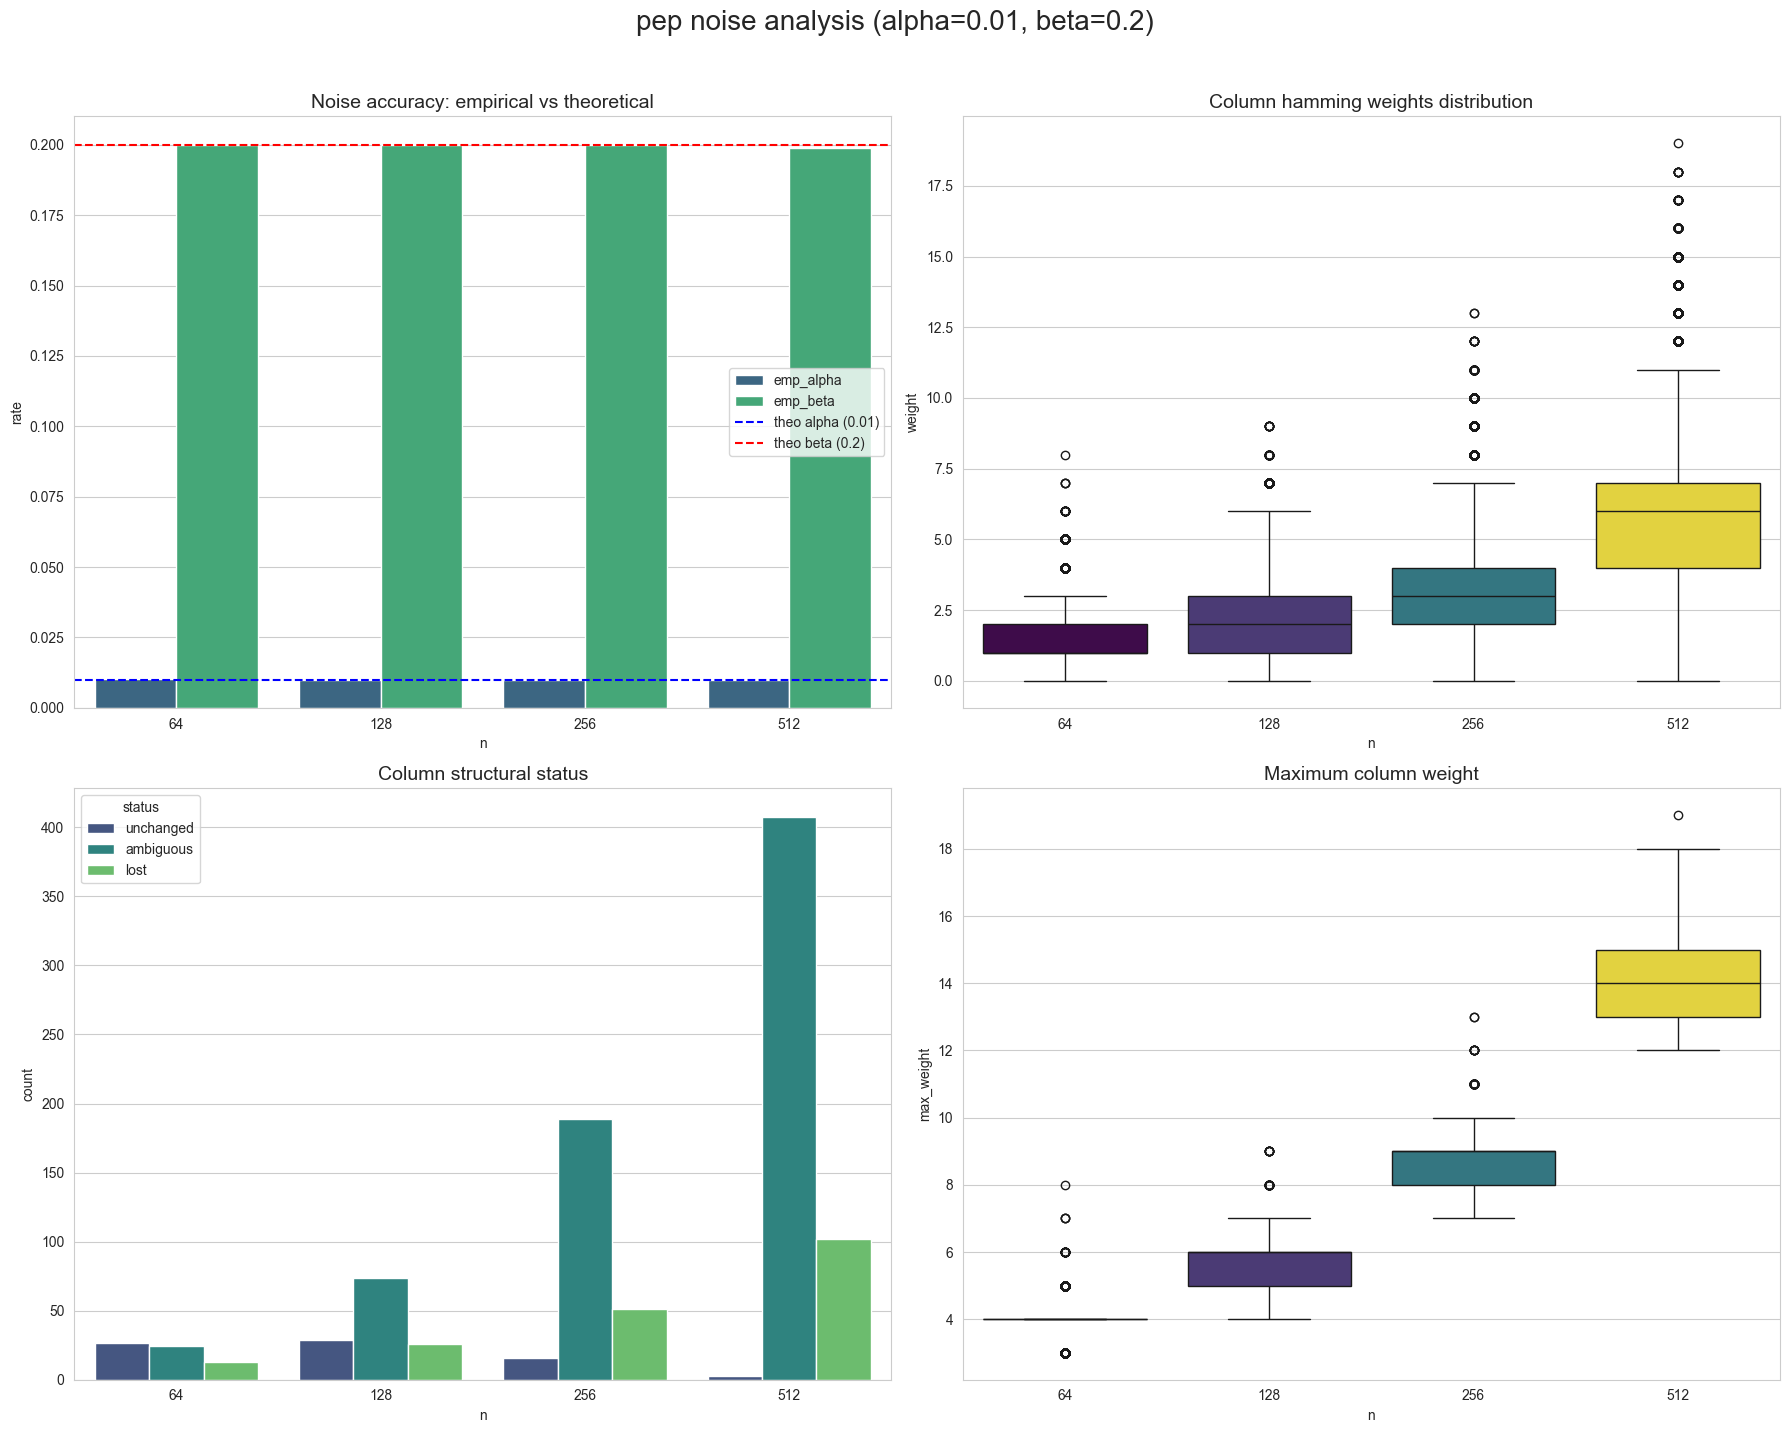


Resumen Promedio por Tamaño de Matriz:
     unchanged  ambiguous     lost  max_weight
n                                             
64      26.918     24.292   12.790       3.977
128     28.675     73.730   25.595       5.823
256     15.668    189.119   51.213       8.936
512      2.394    407.818  101.788      14.021


In [17]:
# generar datos ruidosos para PEP
pep_data = generate_pep_noise_data(NUM_SAMPLES, N_SIZES, ALPHA, BETA)

# métricas
df_stats = analyze_pep_noise(pep_data, ALPHA, BETA)

# resumen de las métricas
summary = df_stats.groupby('n').mean()[['unchanged', 'ambiguous', 'lost', 'max_weight']]
print("\nResumen Promedio por Tamaño de Matriz:")
print(summary)

In [7]:
q = 7
GF = galois.GF(q)

# crear la matriz en F_q
matrix_data = [[2, 4, 2, 1], [1, 2, 0, 3]]
g_fq = GF(matrix_data)

# calcular rref
g_rref = g_fq.row_reduce()

print(f"matrix in F_{q}:")
print(g_rref)

matrix in F_7:
[[1 2 0 3]
 [0 0 1 1]]


In [8]:
# generate random matrix in F_q
q = 7
GF = galois.GF(q)

k, n = 4, 5
g1 = GF.Random((k, n))
print("G1:")
print(g1)

g1_rref = g1.row_reduce()
print("\nG1 rref:")
print(g1_rref)

# generate random P and noisy P
generated_ps = generate_pep_noise_data(1, [n], ALPHA, BETA)
p = generated_ps[0]['original']
p_noisy = generated_ps[0]['noisy']

print("\nOriginal P:")
print(p)
print("\nNoisy P:")
print(p_noisy)

# convert p and p_noisy to galois arrays
p_gf = GF(p)
p_noisy_gf = GF(p_noisy)

# compute g2 = g1 * p (clean version)
# then compute rref to get the canonical generator matrix
g2_raw = g1 @ p_gf
g2 = g2_raw.row_reduce()

# compute g2_noisy = g1 * p_noisy
# note: this might not be a permutation anymore due to noise
g2_noisy_raw = g1 @ p_noisy_gf
g2_noisy = g2_noisy_raw.row_reduce()

print("\ng2 no rref:")
print(g2_raw)

print("\ng2 (rref):")
print(g2)

print("\nnoisy g2 no rref:")
print(g2_noisy_raw)

print("\nnoisy g2 (rref):")
print(g2_noisy)


G1:
[[4 0 2 4 4]
 [4 1 6 1 3]
 [2 0 4 0 5]
 [2 3 3 5 4]]

G1 rref:
[[1 0 0 0 2]
 [0 1 0 0 6]
 [0 0 1 0 2]
 [0 0 0 1 5]]

Original P:
[[0 0 0 1 0]
 [0 1 0 0 0]
 [0 0 0 0 1]
 [1 0 0 0 0]
 [0 0 1 0 0]]

Noisy P:
[[0 0 0 1 0]
 [0 0 0 0 0]
 [0 0 0 0 1]
 [1 0 0 0 0]
 [0 0 1 0 0]]

g2 no rref:
[[4 0 4 4 2]
 [1 1 3 4 6]
 [0 0 5 2 4]
 [5 3 4 2 3]]

g2 (rref):
[[1 0 0 0 1]
 [0 1 0 0 4]
 [0 0 1 0 4]
 [0 0 0 1 6]]

noisy g2 no rref:
[[4 0 4 4 2]
 [1 0 3 4 6]
 [0 0 5 2 4]
 [5 0 4 2 3]]

noisy g2 (rref):
[[1 0 0 0 0]
 [0 0 1 0 0]
 [0 0 0 1 0]
 [0 0 0 0 1]]


In [9]:
def get_pivot_indices(matrix):
        pivots = []
        rows, cols = matrix.shape
        r = 0
        for c in range(cols):
            if r < rows and matrix[r, c] == 1:
                # check if the rest of the column is zero
                if np.count_nonzero(matrix[:, c]) == 1:
                    pivots.append(c)
                    r += 1
        return pivots

def analyze_pivot_stability(g1, g2, g2_noisy):
    # get pivot sets
    piv_g1 = get_pivot_indices(g1.row_reduce())
    piv_g2 = get_pivot_indices(g2) # g2 is already rref
    piv_noisy = get_pivot_indices(g2_noisy) # g2_noisy is already rref

    # stability: pivots that stayed in the same column index between clean and noisy
    stable_pivots = set(piv_g2) & set(piv_noisy)
    stability_count = len(stable_pivots)
    
    # drift: pivots that were lost or shifted
    lost_pivots = len(piv_g2) - stability_count
    new_ghost_pivots = len(piv_noisy) - stability_count

    return {
        'n_pivots_g1': len(piv_g1),
        'n_pivots_g2': len(piv_g2),
        'n_pivots_noisy': len(piv_noisy),
        'stable_pivots': stability_count,
        'stability_rate': stability_count / len(piv_g2) if len(piv_g2) > 0 else 0,
        'lost_pivots': lost_pivots,
        'ghost_pivots': new_ghost_pivots
    }

# example of usage with your previous variables
stats = analyze_pivot_stability(g1, g2, g2_noisy)
print(f"pivots in clean g2: {stats['n_pivots_g2']}")
print(f"pivots that survived noise: {stats['stable_pivots']}")
print(f"stability rate: {stats['stability_rate']:.2%}")

pivots in clean g2: 4
pivots that survived noise: 3
stability rate: 75.00%


In [10]:
def generate_rref_pep_instances(num_samples, n_sizes, k_factor, q, alpha, beta):
    """
    generates full instances: g1, g2, p, p_noisy, g2_noisy
    k_factor: ratio of k/n (e.g., 0.5 for half-rate codes)
    """
    GF = galois.GF(q)
    instances = []
    
    for n in n_sizes:
        k = int(n * k_factor)
        for _ in range(num_samples):
            # g1 and p
            g1 = GF.Random((k, n))
            perm = np.random.permutation(n)
            p = np.zeros((n, n), dtype=int)
            p[np.arange(n), perm] = 1
            
            # g2 = rref(g1 * p)
            g2 = (g1 @ GF(p)).row_reduce()
            
            # p_noisy (hint)
            p_noisy = p.copy()
            p_noisy[(p == 1) & (np.random.random(p.shape) < beta)] = 0
            p_noisy[(p == 0) & (np.random.random(p.shape) < alpha)] = 1
            
            # g2_noisy = rref(g1 * p_noisy)
            g2_noisy = (g1 @ GF(p_noisy)).row_reduce()
            
            instances.append({
                'n': n, 'k': k, 'q': q,
                'g1': g1, 'g2': g2, 'g2_noisy': g2_noisy,
                'p_orig': p, 'p_noisy': p_noisy
            })
    return instances

In [11]:
def analyze_rref_stability(instances):
    stats = []
    
    for inst in instances:
        g2, g2_noisy, n, k = inst['g2'], inst['g2_noisy'], inst['n'], inst['k']
        
        # helper to find pivot columns in rref
        def get_pivots(mat):
            # in rref, pivots are columns of the identity matrix
            pivs = []
            r = 0
            for c in range(mat.shape[1]):
                if r < mat.shape[0] and mat[r, c] == 1:
                    if np.count_nonzero(mat[:, c]) == 1:
                        pivs.append(c)
                        r += 1
            return set(pivs)

        piv_clean = get_pivots(g2)
        piv_noisy = get_pivots(g2_noisy)
        
        # metrics
        stable = piv_clean & piv_noisy
        lost = piv_clean - piv_noisy
        ghosts = piv_noisy - piv_clean
        
        stats.append({
            'n': n,
            'k': k,
            'stability_rate': len(stable) / k if k > 0 else 0,
            'lost_rate': len(lost) / k if k > 0 else 0,
            'new_pivot_rate': len(ghosts) / k if k > 0 else 0,
            'rank_loss': k - len(piv_noisy)
        })
    
    return pd.DataFrame(stats)

generating instances and computing rrefs...


/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: divide by zero encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: overflow encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: invalid value encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: divide by zero encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: overflow encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-pa

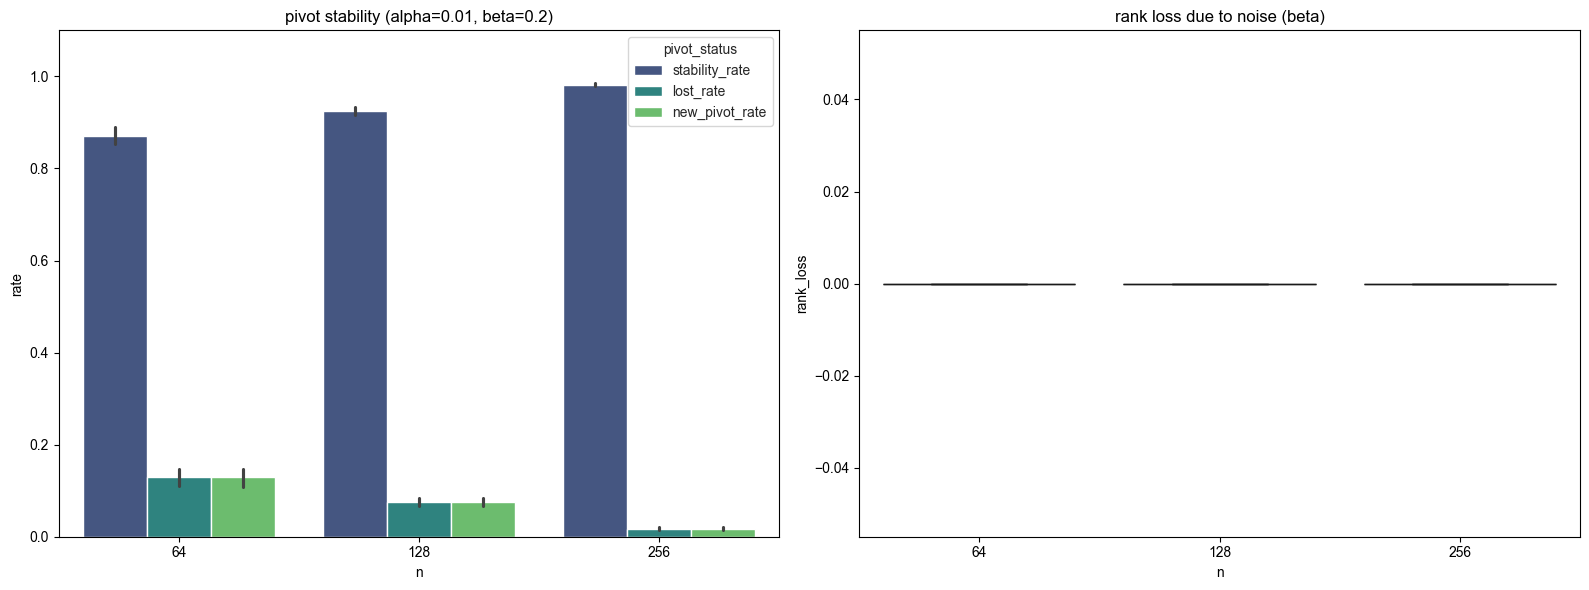


average stats by n:
     stability_rate  lost_rate  rank_loss
n                                        
64         0.870833   0.129167        0.0
128        0.925000   0.075000        0.0
256        0.982292   0.017708        0.0


In [12]:
# settings
NUM_SAMPLES = 30
N_SIZES = [64, 128, 256]
Q = 11
K_FACTOR = 0.75

# run simulation
print("generating instances and computing rrefs...")
instances = generate_rref_pep_instances(NUM_SAMPLES, N_SIZES, K_FACTOR, Q, ALPHA, BETA)
df_rref = analyze_rref_stability(instances)

# plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.set_style("whitegrid")
cmap = "viridis"

# plot 1: pivot stability rates
df_melt = df_rref.melt(id_vars='n', value_vars=['stability_rate', 'lost_rate', 'new_pivot_rate'], 
                       var_name='pivot_status', value_name='rate')
sns.barplot(x='n', y='rate', hue='pivot_status', data=df_melt, ax=axes[0], palette=cmap)
axes[0].set_title(f'pivot stability (alpha={ALPHA}, beta={BETA})')
axes[0].set_ylim(0, 1.1)

# plot 2: rank loss distribution
sns.boxplot(x='n', y='rank_loss', data=df_rref, ax=axes[1], palette=cmap, hue='n', legend=False)
axes[1].set_title('rank loss due to noise (beta)')

plt.tight_layout()
plt.show()

# summary
print("\naverage stats by n:")
print(df_rref.groupby('n')[['stability_rate', 'lost_rate', 'rank_loss']].mean())

In [ ]:
def solve_pep_with_tree(g1, g2, p_noisy, q):
    k, n = g1.shape
    GF = galois.GF(q)
    g2_target = g2
    
    # clasification of candidates by column
    high_priority = []  # Lists of rows with '1' per column
    low_priority = []   # Lists of rows with '0' per column
    ones_per_col = []
    
    for c in range(n):
        ones = np.where(p_noisy[:, c] == 1)[0].tolist()
        zeros = np.where(p_noisy[:, c] == 0)[0].tolist()
        high_priority.append(ones)
        low_priority.append(zeros)
        ones_per_col.append(len(ones))
        
    # determine the strict order of columns to explore
    cols_with_one_1 = [c for c in range(n) if ones_per_col[c] == 1] # columns with exactly one '1' (high confidence)
    cols_with_multi_1 = [c for c in range(n) if ones_per_col[c] > 1] # columns with multiple '1's (ambiguous)
    # Sort columns with more than one '1' from least to most ones
    cols_with_multi_1.sort(key=lambda c: ones_per_col[c])
    cols_with_zero_1 = [c for c in range(n) if ones_per_col[c] == 0] # columns with no '1's (low confidence)
    
    col_order = cols_with_one_1 + cols_with_multi_1 + cols_with_zero_1
    
    # backtracking variables
    attempts = 0 # number of attempts until finding the solution
    used_rows = [False] * n # used to mark which rows have been assigned in the current path
    current_p_indices = [-1] * n # current assignment of rows for each column in the path
    recovered_p = None # result variable to store the recovered P if found
    
    # structure to record the tree: (parent_id, node_id, label)
    tree_edges = []
    node_counter = 0
    
    def check_solution(indices):
        nonlocal attempts, recovered_p
        attempts += 1
        p_test = np.zeros((n, n), dtype=int)
        for c, r in enumerate(indices):
            p_test[r, c] = 1
        
        # validation in the finite field: RREF(g1 * p_test) should equal g2_target
        g2_test = (g1 @ GF(p_test)).row_reduce()
        if np.array_equal(g2_test, g2_target):
            recovered_p = p_test
            return True
        return False

    def backtrack(order_idx, parent_node_id):
        nonlocal node_counter
        
        # If all columns have been assigned, check the solution of the linear system
        if order_idx == n:
            return check_solution(current_p_indices)
            
        col = col_order[order_idx]
        
        # Group candidates according to the specification: first the 1s, then the 0s
        candidates = high_priority[col] + low_priority[col]
        
        for row in candidates:
            if not used_rows[row]:
                node_counter += 1
                current_node_id = node_counter
                
                # Record the edge in the exploration tree
                is_high_priority = row in high_priority[col]
                edge_label = f"C{col}:R{row} ({'1' if is_high_priority else '0'})"
                tree_edges.append((parent_node_id, current_node_id, edge_label))
                
                # move forward to the next level (set the current column to this row)
                used_rows[row] = True
                current_p_indices[col] = row
                
                # Recursive call to the next level
                if backtrack(order_idx + 1, current_node_id):
                    return True
                    
                # Backtrack: undo the move
                used_rows[row] = False
                current_p_indices[col] = -1
                
        return False

    # The root node (0) represents the empty initial state
    success = backtrack(0, parent_node_id=0)
    
    return success, attempts, recovered_p, tree_edges, col_order


def plot_search_tree(tree_edges, col_order):
    """
    Draws the decision tree taken by the backtracking algorithm
    with a purely hierarchical layout (root at the top, branches below).
    """
    G = nx.DiGraph()
    edge_labels = {}
    
    # 1. Build the graph and record edges
    for parent, child, label in tree_edges:
        G.add_edge(parent, child)
        edge_labels[(parent, child)] = label
        
    if len(G) == 0:
        print("The tree is empty. No transitions to plot.")
        return

    # 2. Internal function to manually calculate hierarchical positions
    def hierarchy_pos(G, root, width=1.0, vert_gap=0.2, vert_loc=0, xcenter=0.5, pos=None, cleaved={}):
        if pos is None:
            pos = {root: (xcenter, vert_loc)}
        else:
            pos[root] = (xcenter, vert_loc)
            
        neighbors = list(G.neighbors(root))
        if len(neighbors) != 0:
            dx = width / len(neighbors) 
            nextx = xcenter - width/2 - dx/2
            for neighbor in neighbors:
                nextx += dx
                pos = hierarchy_pos(G, neighbor, width=dx, vert_gap=vert_gap, 
                                    vert_loc=vert_loc-vert_gap, xcenter=nextx, pos=pos)
        return pos

    # Assume the root is always node 0 according to the previous algorithm
    root_node = 0
    pos = hierarchy_pos(G, root_node)

    # 3. Classify node colors for better intuition
    node_colors = []
    for node in G.nodes():
        if node == root_node:
            node_colors.append("lightgreen") # Highlighted root at the top
        elif G.out_degree(node) == 0 and len(G.in_edges(node)) > 0:
            # It's a leaf node. If it's the last explored node of success, highlight it
            node_colors.append("gold" if node == max(G.nodes()) else "lightcoral")
        else:
            node_colors.append("lightblue") # Intermediate branching nodes

    # 4. Render the graph
    plt.figure(figsize=(16, 10))
    plt.title(f"Hierarchical Search Tree - Backtracking PEP\nProcessed Column Order: {col_order}", fontsize=14, pad=20)
    
    # Draw nodes with their assigned colors
    nx.draw_networkx_nodes(G, pos, node_size=500, node_color=node_colors, edgecolors="black", linewidths=1)
    
    # Draw arrows for branches pointing downwards
    nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=15, edge_color="gray", width=1.5)
    
    # Add labels to nodes
    nx.draw_networkx_labels(G, pos, font_size=9, font_family="sans-serif", font_weight="bold")
    
    # Draw edge labels (C: Column, R: Row, Hint)
    # We use a horizontal rotation angle to improve readability in cascade
    nx.draw_networkx_edge_labels(
        G, pos, 
        edge_labels=edge_labels, 
        font_size=8, 
        label_pos=0.5, 
        rotate=False,
        bbox=dict(facecolor='white', edgecolor='none', alpha=0.7, boxstyle='round,pad=0.2')
    )
    
    plt.axis("off")
    plt.tight_layout()
    plt.show()


G1:
[[3 1 3 0 0 5 0 5]
 [3 2 5 2 6 1 3 1]
 [4 5 0 1 6 0 0 6]
 [5 5 4 0 0 5 5 5]
 [0 5 3 6 5 1 1 5]]
G2:
[[1 0 0 0 0 6 6 2]
 [0 1 0 0 0 6 5 0]
 [0 0 1 0 0 0 0 5]
 [0 0 0 1 0 6 2 1]
 [0 0 0 0 1 1 1 0]]

Original P:
[[0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]]

Noisy P:
[[0 0 0 1 0 0 0 0]
 [1 0 0 0 0 1 0 0]
 [0 0 0 0 1 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 0 0]]
solution found: True
recovered P:
[[0 0 0 1 0 0 0 0]
 [1 0 0 0 0 0 0 0]
 [0 0 0 0 0 1 0 0]
 [0 0 0 0 1 0 0 0]
 [0 1 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1]
 [0 0 1 0 0 0 0 0]
 [0 0 0 0 0 0 1 0]]
total permutations tested: 3
stage reached: 13
Total possible permutations: 40320
Tree explored:


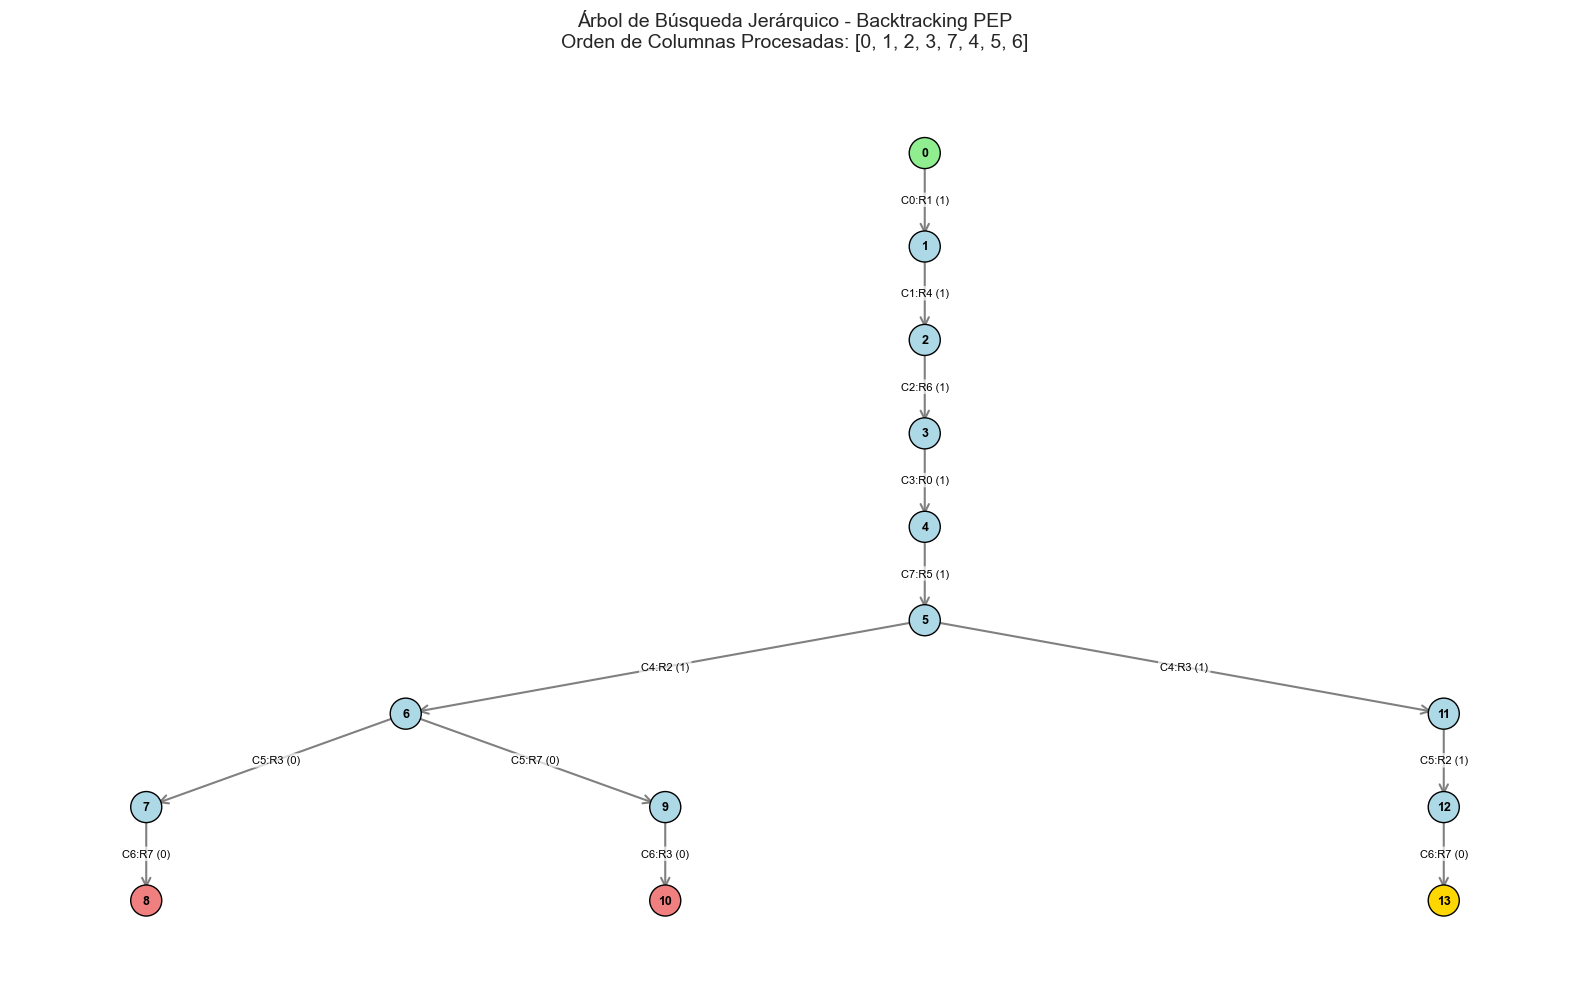

In [42]:
q = 7
n, k = 8, 5 # test with small n
GF = galois.GF(q)
g1 = GF.Random((k, n))
perm = np.random.permutation(n)
p_real = np.zeros((n, n), dtype=int)
p_real[np.arange(n), perm] = 1
g2 = (g1 @ GF(p_real)).row_reduce()
print("G1:")
print(g1)
print("G2:")
print(g2)
print("\nOriginal P:")
print(p_real)

# create noise (alpha and beta)
p_noisy = p_real.copy()
p_noisy[p_real == 1] = (np.random.random(n) > 0.2).astype(int) # beta
p_noisy[p_real == 0] = (np.random.random(n*(n-1)) < 0.01).astype(int).reshape(n, n-1).flatten() # alpha
print("\nNoisy P:")
print(p_noisy)

success, attempts, recovered_p, tree_edges, col_order = solve_pep_with_tree(g1, g2, p_noisy, q)

print(f"solution found: {success}")
print("recovered P:")
print(recovered_p)
print(f"total permutations tested: {attempts}")
print(f"stage reached: {len(tree_edges)}")
print(f"Total possible permutations: {math.factorial(n)}")
print(f"Tree explored:")
plot_search_tree(tree_edges, col_order)

In [43]:
def run_simulation(timeout_sec=300):
    # parametros de las pruebas
    test_cases = [
        (11, 5, 7),
        (32, 12, 31), 
        (64, 35, 127)
    ]
    n_instances = 100
    results = []

    for n, k, q in test_cases:
        print(f"--- Probando configuración n={n}, k={k}, q={q} ---")
        GF = galois.GF(q)
        possible_perms = math.factorial(n)
        
        for i in range(n_instances):
            # generación de G1, P_real y G2
            g1 = GF.Random((k, n))
            perm = np.random.permutation(n)
            p_real = np.zeros((n, n), dtype=int)
            p_real[np.arange(n), perm] = 1
            g2 = (g1 @ GF(p_real)).row_reduce()

            # creación de ruido
            p_noisy = p_real.copy()
            # Beta: probabilidad de que un 1 pase a 0
            p_noisy[p_real == 1] = (np.random.random(n) > BETA).astype(int) 
            # Alpha: probabilidad de que un 0 pase a 1
            noise_zeros = (np.random.random(n*(n-1)) < ALPHA).astype(int)
            p_noisy[p_real == 0] = noise_zeros

            # Ejecución y medición de tiempo
            start_time = time.time()
            
            try:
                # Intentamos ejecutar la función con el timeout especificado
                success, attempts, _ , tree_edges, _ = func_timeout(
                    timeout_sec, solve_pep_with_tree, args=(g1, g2, p_noisy, q)
                )
                print(f"Instancia {i+1} completada: found={success}, attempts={attempts}, stage={len(tree_edges)}")
            except FunctionTimedOut:
                # Si excede el tiempo, definimos valores por defecto para el fallo
                success, attempts, _ , tree_edges, _ = False, -1, None, [], []
                print(f"Instancia {i+1} abortada por timeout (> {timeout_sec}s)")
            except Exception as e:
                # Captura otros errores posibles
                success, attempts, _ , tree_edges, _ = False, -1, None, [], []
                print(f"Instancia {i+1} abortada por error: {str(e)}")
            end_time = time.time()

            # almacenar resultados
            results.append({
                'n': n,
                'k': k,
                'q': q,
                'found': success,
                'attempts': attempts,
                'possible_permutations': possible_perms,
                'execution_time_sec': end_time - start_time,
            })

            df_results_checkpoint = pd.DataFrame(results)
            df_results_checkpoint.to_csv('pep_rref_backtracking_results_checkpoint.csv', index=False)
            
            # Print de progreso cada 20 instancias
            if (i + 1) % 20 == 0:
                print(f"Instancia {i+1}/{n_instances} completada.")

    # Crear el DataFrame final
    df = pd.DataFrame(results)
    return df

# ejecutar la simulación
df_resultados = run_simulation()

# Mostrar un resumen estadístico por grupo
resumen = df_resultados.groupby(['n', 'k', 'q']).agg({
    'attempts': ['mean', 'max'],
    'execution_time_sec': ['mean', 'sum'],
    'found': 'sum'
}).reset_index()

print(resumen)


--- Probando configuración n=11, k=5, q=7 ---
Instancia 1 completada: found=True, attempts=1, stage=11
Instancia 2 completada: found=True, attempts=17, stage=53
Instancia 3 completada: found=True, attempts=2, stage=13
Instancia 4 completada: found=True, attempts=1, stage=11
Instancia 5 completada: found=True, attempts=1, stage=11
Instancia 6 completada: found=True, attempts=2, stage=13
Instancia 7 completada: found=True, attempts=1, stage=11
Instancia 8 completada: found=True, attempts=88, stage=245
Instancia 9 completada: found=True, attempts=1, stage=11
Instancia 10 completada: found=True, attempts=5, stage=21
Instancia 11 completada: found=True, attempts=846, stage=2306
Instancia 12 completada: found=True, attempts=7, stage=27
Instancia 13 completada: found=True, attempts=1, stage=11
Instancia 14 completada: found=True, attempts=1, stage=11
Instancia 15 completada: found=True, attempts=1, stage=11
Instancia 16 completada: found=True, attempts=1, stage=11
Instancia 17 completada: fou

/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: divide by zero encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: overflow encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: invalid value encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: divide by zero encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-packages/galois/_domains/_linalg.py:60: RuntimeWarning: overflow encountered in matmul
  c = function(a, b, out=out)
/Users/estefanialaverdebecerra/Library/Python/3.9/lib/python/site-pa

Instancia 1 abortada por timeout (> 300s)
Instancia 2 abortada por timeout (> 300s)
Instancia 3 abortada por timeout (> 300s)
Instancia 4 abortada por timeout (> 300s)
Instancia 5 abortada por timeout (> 300s)
Instancia 6 abortada por timeout (> 300s)
Instancia 7 abortada por timeout (> 300s)
Instancia 8 abortada por timeout (> 300s)
Instancia 9 abortada por timeout (> 300s)
Instancia 10 abortada por timeout (> 300s)
Instancia 11 abortada por timeout (> 300s)
Instancia 12 abortada por timeout (> 300s)
Instancia 13 abortada por timeout (> 300s)
Instancia 14 abortada por timeout (> 300s)
Instancia 15 abortada por timeout (> 300s)
Instancia 16 abortada por timeout (> 300s)
Instancia 17 abortada por timeout (> 300s)
Instancia 18 abortada por timeout (> 300s)
Instancia 19 abortada por timeout (> 300s)
Instancia 20 abortada por timeout (> 300s)
Instancia 20/100 completada.
Instancia 21 abortada por timeout (> 300s)
Instancia 22 abortada por timeout (> 300s)
Instancia 23 abortada por timeout 

In [44]:
resumen

n   k    q attempts         execution_time_sec               found
                   mean     max               mean           sum   sum
0  11   5    7  9345.90  362890          12.229141   1222.914143    97
1  32  12   31  9834.73  365445         256.992947  25699.294746    17
2  64  35  127    -1.00      -1         514.086844  51408.684433     0